# Лабораторная работа №2
## Технологии машинного обучения

**Тема:** Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Студент:** Артёмова Дарья Артёмовна
**Группа:** ИБМ3-64Б

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.datasets import fetch_california_housing

# Настройка отображения графиков в Jupyter
%matplotlib inline

# Отключение предупреждений (для чистоты вывода)
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно загружены!")

Библиотеки успешно загружены!


## Часть 1. Работа с датасетом Titanic (пропуски и категориальные признаки)

In [2]:
# Загрузка датасета Titanic
titanic = sns.load_dataset('titanic')

# Вывод первых 5 строк
print("Первые 5 строк датасета:")
print(titanic.head())

# Информация о датасете (типы данных, количество ненулевых значений)
print("\nИнформация о датасете:")
print(titanic.info())

# Количество пропусков в каждом столбце
print("\nКоличество пропусков по столбцам:")
print(titanic.isnull().sum())

Первые 5 строк датасета:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ----

### 1.1 Обработка пропусков

In [3]:
# Создаем копию датасета, чтобы не испортить исходные данные
titanic_clean = titanic.copy()

# 1. Заполняем пропуски в возрасте (age) медианным значением
median_age = titanic_clean['age'].median()
titanic_clean['age'].fillna(median_age, inplace=True)
print(f"Пропуски в age заполнены медианой: {median_age}")

# 2. Удаляем строки с пропусками в столбце embarked (порт посадки)
#    (таких строк всего 2, удаление не критично)
titanic_clean.dropna(subset=['embarked'], inplace=True)

# 3. Удаляем столбец deck, так как в нем более 70% пропусков
titanic_clean.drop(columns=['deck'], inplace=True)
print("Столбец 'deck' удален (более 70% пропусков)")

# Проверка: остались ли пропуски?
print(f"\nОбщее количество пропусков после обработки: {titanic_clean.isnull().sum().sum()}")

Пропуски в age заполнены медианой: 28.0
Столбец 'deck' удален (более 70% пропусков)

Общее количество пропусков после обработки: 0


In [10]:
print("Первые 5 строк после обработки пропусков:")
print(titanic_clean.head())
print("\nИнформация о пропусках после обработки:")
print(titanic_clean.isnull().sum())

Первые 5 строк после обработки пропусков:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  

Информация о пропусках после обработки:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who          

### 1.2 Кодирование категориальных признаков

In [7]:
# Снова создаем копию для кодирования (чтобы иметь чистый исходник)
titanic_encoded = titanic_clean.copy()

# Кодирование 1: Label Encoding для признака 'sex' (male/female -> 0/1)
le = LabelEncoder()
titanic_encoded['sex_encoded'] = le.fit_transform(titanic_encoded['sex'])
print("Label Encoding для 'sex':")
print(f"  male -> {le.transform(['male'])[0]}")
print(f"  female -> {le.transform(['female'])[0]}")

# Кодирование 2: One-Hot Encoding для признака 'embarked' (S/C/Q)
embarked_dummies = pd.get_dummies(titanic_encoded['embarked'], prefix='embarked')
titanic_encoded = pd.concat([titanic_encoded, embarked_dummies], axis=1)
print("\nOne-Hot Encoding для 'embarked': созданы столбцы:")
print(embarked_dummies.columns.tolist())

# Удаляем исходные текстовые столбцы, которые больше не нужны
columns_to_drop = ['sex', 'embarked', 'alive', 'who', 'class', 'adult_male', 'embark_town']
titanic_encoded.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("\nИтоговые столбцы после кодирования:")
print(titanic_encoded.columns.tolist())

Label Encoding для 'sex':
  male -> 1
  female -> 0

One-Hot Encoding для 'embarked': созданы столбцы:
['embarked_C', 'embarked_Q', 'embarked_S']

Итоговые столбцы после кодирования:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_encoded', 'embarked_C', 'embarked_Q', 'embarked_S']


In [9]:
print("Первые 5 строк после кодирования:")
print(titanic_encoded.head())

Первые 5 строк после кодирования:
   survived  pclass   age  sibsp  parch     fare  alone  sex_encoded  \
0         0       3  22.0      1      0   7.2500  False            1   
1         1       1  38.0      1      0  71.2833  False            0   
2         1       3  26.0      0      0   7.9250   True            0   
3         1       1  35.0      1      0  53.1000  False            0   
4         0       3  35.0      0      0   8.0500   True            1   

   embarked_C  embarked_Q  embarked_S  
0       False       False        True  
1        True       False       False  
2       False       False        True  
3       False       False        True  
4       False       False        True  


## Часть 2. Масштабирование данных (датасет California Housing)

In [11]:
# Загрузка датасета California Housing
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame

print("Первые 5 строк датасета California Housing:")
print(df_housing.head())

print("\nСтатистика признаков (до масштабирования):")
print(df_housing.describe())

Первые 5 строк датасета California Housing:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Статистика признаков (до масштабирования):
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173   

In [12]:
# Отделяем признаки (X) от целевой переменной (y)
X = df_housing.drop('MedHouseVal', axis=1)
y = df_housing['MedHouseVal']

print("Признаки (размерность):", X.shape)
print("Целевая переменная (размерность):", y.shape)
print("\nНазвания признаков:")
print(X.columns.tolist())

Признаки (размерность): (20640, 8)
Целевая переменная (размерность): (20640,)

Названия признаков:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### 2.1 MinMaxScaler (нормализация в диапазон [0, 1])

In [13]:
# MinMaxScaler: приводит все значения к диапазону [0, 1]
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

print("Статистика после MinMaxScaler:")
print(X_minmax_df.describe())

Статистика после MinMaxScaler:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       0.232464      0.541951      0.032488      0.022629      0.039869   
std        0.131020      0.246776      0.017539      0.014049      0.031740   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.142308      0.333333      0.025482      0.019943      0.021974   
50%        0.209301      0.549020      0.031071      0.021209      0.032596   
75%        0.292641      0.705882      0.036907      0.022713      0.048264   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       0.001914      0.328572      0.476125  
std        0.008358      0.226988      0.199555  
min        0.000000      0.000000      0.000000  
25%    

### 2.2 StandardScaler (стандартизация: среднее=0, дисперсия=1)

In [14]:
# StandardScaler: приводит к среднему 0 и стандартному отклонению 1
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=X.columns)

print("Статистика после StandardScaler:")
print(X_std_df.describe())

Статистика после StandardScaler:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  2.064000e+04  2.064000e+04  2.064000e+04  2.064000e+04  2.064000e+04   
mean   6.609700e-17  5.508083e-18  6.609700e-17 -1.060306e-16 -1.101617e-17   
std    1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00   
min   -1.774299e+00 -2.196180e+00 -1.852319e+00 -1.610768e+00 -1.256123e+00   
25%   -6.881186e-01 -8.453931e-01 -3.994496e-01 -1.911716e-01 -5.638089e-01   
50%   -1.767951e-01  2.864572e-02 -8.078489e-02 -1.010650e-01 -2.291318e-01   
75%    4.593063e-01  6.643103e-01  2.519615e-01  6.015869e-03  2.644949e-01   
max    5.858286e+00  1.856182e+00  5.516324e+01  6.957171e+01  3.025033e+01   

           AveOccup      Latitude     Longitude  
count  2.064000e+04  2.064000e+04  2.064000e+04  
mean   3.442552e-18 -1.079584e-15 -8.526513e-15  
std    1.000024e+00  1.000024e+00  1.000024e+00  
min   -2.290000e-01 -1.447568e+00 -2.385992e+00  
25%  

### 2.3 Сравнение масштабирования на одном признаке (AveRooms)

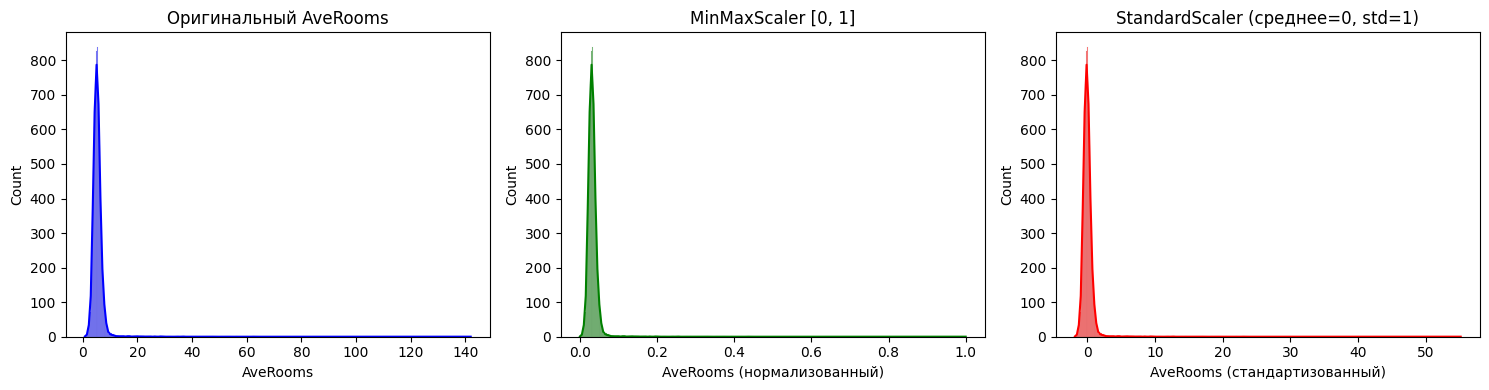

In [15]:
# Визуализация распределения признака AveRooms до и после масштабирования
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Оригинальные данные
sns.histplot(X['AveRooms'], ax=axes[0], kde=True, color='blue')
axes[0].set_title('Оригинальный AveRooms')
axes[0].set_xlabel('AveRooms')

# После MinMaxScaler
sns.histplot(X_minmax_df['AveRooms'], ax=axes[1], kde=True, color='green')
axes[1].set_title('MinMaxScaler [0, 1]')
axes[1].set_xlabel('AveRooms (нормализованный)')

# После StandardScaler
sns.histplot(X_std_df['AveRooms'], ax=axes[2], kde=True, color='red')
axes[2].set_title('StandardScaler (среднее=0, std=1)')
axes[2].set_xlabel('AveRooms (стандартизованный)')

plt.tight_layout()
plt.show()

### 2.4 Визуализация распределения возраста (обработка пропусков на Titanic)

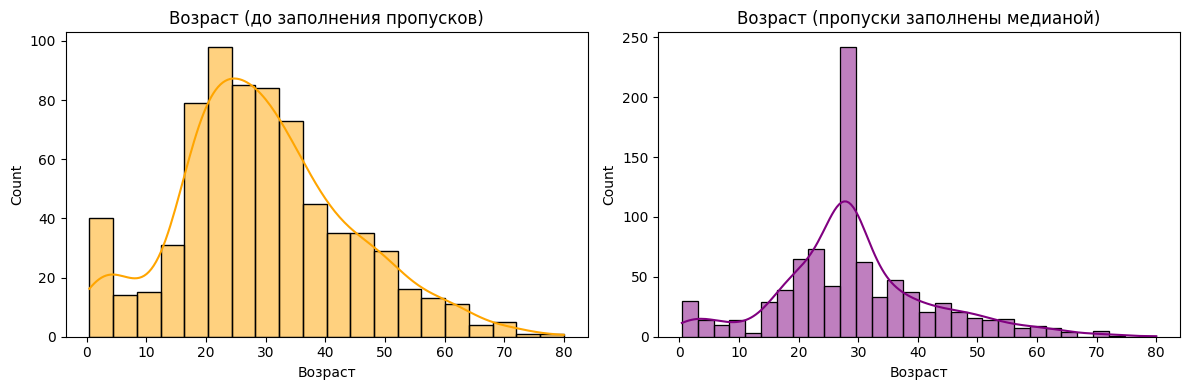

Количество записей ДО заполнения пропусков: 714
Количество записей ПОСЛЕ заполнения пропусков: 889


In [16]:
# Сравнение распределения возраста ДО и ПОСЛЕ заполнения пропусков
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# До обработки (только существующие значения)
sns.histplot(titanic['age'].dropna(), ax=axes[0], kde=True, color='orange')
axes[0].set_title('Возраст (до заполнения пропусков)')
axes[0].set_xlabel('Возраст')

# После обработки
sns.histplot(titanic_clean['age'], ax=axes[1], kde=True, color='purple')
axes[1].set_title('Возраст (пропуски заполнены медианой)')
axes[1].set_xlabel('Возраст')

plt.tight_layout()
plt.show()

print(f"Количество записей ДО заполнения пропусков: {titanic['age'].notna().sum()}")
print(f"Количество записей ПОСЛЕ заполнения пропусков: {titanic_clean['age'].notna().sum()}")

## Выводы по работе

### Выводы:

1. **Обработка пропусков:**
   - Пропуски в числовых признаках (age) были заполнены медианой — это позволяет сохранить все данные, не удаляя строки.
   - Столбец deck удален из-за слишком большого количества пропусков (>70%).
   - Строки с пропусками в embarked удалены (всего 2 строки, это не повлияло на анализ).

2. **Кодирование категориальных признаков:**
   - Label Encoding применен для бинарного признака sex (male/female → 0/1).
   - One-Hot Encoding применен для признака embarked с 3 категориями (S/C/Q), создано 3 новых бинарных столбца.
   - Кодирование позволяет преобразовать текстовые данные в числовой формат, понятный для моделей машинного обучения.

3. **Масштабирование данных:**
   - MinMaxScaler приводит все признаки к диапазону [0, 1] — полезно для методов, чувствительных к масштабу (например, нейронные сети, SVM).
   - StandardScaler приводит признаки к распределению со средним 0 и дисперсией 1 — полезно для линейных моделей и PCA.
   - Масштабирование необходимо, когда признаки имеют разные единицы измерения и диапазоны значений.

**Итог:** Все три этапа предобработки данных (пропуски, кодирование, масштабирование) успешно выполнены. Данные готовы для построения моделей машинного обучения.

In [17]:
# Сохранение обработанных данных в CSV
titanic_encoded.to_csv('titanic_processed.csv', index=False)
X_minmax_df.to_csv('california_minmax.csv', index=False)
X_std_df.to_csv('california_standard.csv', index=False)

print("Обработанные данные сохранены в CSV файлы.")

Обработанные данные сохранены в CSV файлы.
